In [ ]:
import os
os.chdir('/content')
print(f"Diretório atual: {os.getcwd()}")

Diretório atual: /content


In [ ]:
# ── Célula 1: limpar o clone antigo ──────────────────────────────────────
import shutil, os

# Remove o clone anterior
if os.path.exists('/content/Mercado-Artificial-Fiis'):
    shutil.rmtree('/content/Mercado-Artificial-Fiis')
    print("✓ Clone anterior removido")

In [1]:
import os
import copy
import warnings
import itertools
import datetime as dt
import pandas as pd
import numpy as np
import random # Usado para random.sample e random.shuffle
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import yfinance as yf
from dataclasses import dataclass, field
from typing import List, Dict, Optional
from scipy.stats import norm, skew, kurtosis, truncnorm, jarque_bera, shapiro # Importar diretamente as funções
from statsmodels.tsa.stattools import acf
from statsmodels.graphics.tsaplots import plot_acf
from scipy.optimize import curve_fit
from statsmodels.graphics.gofplots import qqplot
from multiprocessing import Pool
import random
import traceback # Importar para printar o traceback em caso de erro

# Importar nas classes quando usar função standalone

warnings.filterwarnings("ignore")

In [2]:
!git clone https://github.com/gilbertogilfgp/Mercado-Artificial-Fiis.git
%cd /content/Mercado-Artificial-Fiis

import sys
sys.path.append('/content/Mercado-Artificial-Fiis')

!pip install numpy pandas matplotlib scipy statsmodels yfinance seaborn

Cloning into 'Mercado-Artificial-Fiis'...
remote: Enumerating objects: 199, done.
remote: Counting objects: 100% (6/6), done.
remote: Compressing objects: 100% (6/6), done.
remote: Total 199 (delta 1), reused 0 (delta 0), pack-reused 193 (from 2)
Receiving objects: 100% (199/199), 12.72 MiB | 7.51 MiB/s, done.
Resolving deltas: 100% (100/100), done.
Updating files: 100% (21/21), done.
/content/Mercado-Artificial-Fiis


# Funções

## MCR

In [ ]:
def cobertura_mcr(
    df_simulacoes: pd.DataFrame,
    df_unica: pd.DataFrame,
    num_dias: int,
    col_sim: str = "simulacao",
    col_retorno: str = "log_return",
    lags_acf: list = [5, 10, 15, 20],
    lags_acf2: list = [1, 2],
    fft: bool = True,
) -> tuple[pd.DataFrame, float, pd.DataFrame]:

    sims = df_simulacoes[col_sim].unique()
    momentos_ref = df_unica["Momento"].astype(str).tolist()
    ic = df_unica.set_index("Momento")[["IC 95% inf", "IC 95% sup"]].to_dict("index")

    hits = {m: 0 for m in momentos_ref}
    joint_hits = 0
    flags_rows = []

    for k in sims:
        df_k = df_simulacoes[df_simulacoes[col_sim] == k].tail(num_dias)
        r = df_k[col_retorno].to_numpy(dtype=float)
        r = r[np.isfinite(r)]

        # Calcular momentos com nomes iguais ao df_unica
        m_sim = {}
        m_sim["Media"]      = float(np.mean(r))
        m_sim["Variancia"]  = float(np.var(r, ddof=1))
        m_sim["Assimetria"] = float(skew(r, bias=False))
        m_sim["Curtose"]    = float(kurtosis(r, fisher=False, bias=False))

        acf_r = acf(r, nlags=max(lags_acf), fft=fft)
        for L in lags_acf:
            m_sim[f"acf_{L}"] = float(acf_r[L])

        acf_q = acf(r**2, nlags=max(lags_acf2), fft=fft)
        for L in lags_acf2:
            m_sim[f"autocorr_q_{L}"] = float(acf_q[L])

        # Avaliar cobertura
        all_inside = True
        row_flags = {"simulacao": k}

        for m in momentos_ref:
            val = m_sim.get(m, np.nan)
            lo = ic[m]["IC 95% inf"]
            hi = ic[m]["IC 95% sup"]

            inside = np.isfinite(val) and (val >= lo) and (val <= hi)
            row_flags[m] = inside
            hits[m] += int(inside)
            all_inside = all_inside and inside

        row_flags["joint"] = all_inside
        flags_rows.append(row_flags)
        joint_hits += int(all_inside)

    n_sim = len(sims)
    df_cob = pd.DataFrame({
        "Momento": momentos_ref,
        "Cobertura (%)": [100 * hits[m] / n_sim for m in momentos_ref]
    })
    joint_mcr = 100 * joint_hits / n_sim
    df_flags = pd.DataFrame(flags_rows)

    return df_cob, joint_mcr, df_flags

## Calcular momentos simulações

In [ ]:
def calcular_momentos_simulacoes(
    df_simulacoes: pd.DataFrame,
    num_dias: int = 60,
    col_sim: str = "simulacao",
    col_retorno: str = "log_return",
    lags_acf: list = [5, 10, 15, 20],
    lags_acf2: list = [1, 2],
    fft: bool = True,
) -> pd.DataFrame:
    """
    Calcula os momentos dos últimos num_dias para cada simulação.
    Retorna DataFrame com shape (n_simulacoes x 10 momentos).
    """
    sims = sorted(df_simulacoes[col_sim].dropna().unique())
    resultados = []

    for k in sims:
        df_k = df_simulacoes[df_simulacoes[col_sim] == k].tail(num_dias)
        r = df_k[col_retorno].dropna().to_numpy(dtype=float)

        row = {"simulacao": k}
        row["Media"]      = float(np.mean(r))
        row["Variancia"]  = float(np.var(r, ddof=1))
        row["Assimetria"] = float(skew(r, bias=False))
        row["Curtose"]    = float(kurtosis(r, fisher=False, bias=False))

        acf_r = acf(r, nlags=max(lags_acf), fft=fft)
        for L in lags_acf:
            row[f"acf_{L}"] = float(acf_r[L])

        acf_q = acf(r**2, nlags=max(lags_acf2), fft=fft)
        for L in lags_acf2:
            row[f"autocorr_q_{L}"] = float(acf_q[L])

        resultados.append(row)

    return pd.DataFrame(resultados).set_index("simulacao")

## Plotar momentos

In [ ]:
def plotar_distribuicoes_momentos_separados(
    df_momentos_sim,
    df_unica,
    col_sim="simulacao",
    col_momento_ref="Momento",
    col_media_ref="Média do bootstrap",
    col_ic_inf="IC 95% inf",
    col_ic_sup="IC 95% sup",
    bins=30,
    density=True,
    figsize=(8, 4.8)
):
    """
    Gera um gráfico para cada momento:
    histograma das simulações + média bootstrap + faixa IC95%.
    """
    momentos = df_unica[col_momento_ref].tolist()

    for momento in momentos:
        if momento not in df_momentos_sim.columns:
            print(f"Aviso: momento '{momento}' não encontrado nas simulações. Pulando.")
            continue

        valores = df_momentos_sim[momento].dropna().to_numpy(dtype=float)

        linha_ref = df_unica[df_unica[col_momento_ref] == momento].iloc[0]
        media_boot = linha_ref[col_media_ref]
        ic_inf = linha_ref[col_ic_inf]
        ic_sup = linha_ref[col_ic_sup]

        plt.figure(figsize=figsize)
        plt.hist(valores, bins=bins, density=density, alpha=0.6, edgecolor="black")

        plt.axvline(media_boot, linestyle="--", linewidth=2, label="Média bootstrap")
        plt.axvspan(ic_inf, ic_sup, alpha=0.2, label="IC 95% bootstrap")

        plt.title(f"Distribuição simulada de {momento}")
        plt.xlabel(momento)
        plt.ylabel("Densidade" if density else "Frequência")
        plt.legend()
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()

In [ ]:
def plotar_distribuicoes_momentos(
    df_momentos_sim,
    df_unica,
    col_sim="simulacao",
    col_momento_ref="Momento",
    col_media_ref="Média do bootstrap",
    col_ic_inf="IC 95% inf",
    col_ic_sup="IC 95% sup",
    bins=30,
    density=True,
    figsize=(20, 15)  # Ajustado para caber a matriz 3x4
):
    """
    Gera todos os gráficos de momentos em uma matriz 3x4:
    histograma das simulações + média bootstrap + faixa IC95%.
    """
    momentos = df_unica[col_momento_ref].tolist()

    # Cria a figura e a matriz de subplots 3x4
    fig, axes = plt.subplots(3, 4, figsize=figsize)
    axes = axes.flatten()  # Facilita a iteração sobre os 12 slots

    for i, momento in enumerate(momentos):
        if momento not in df_momentos_sim.columns:
            print(f"Aviso: momento '{momento}' não encontrado nas simulações. Pulando.")
            continue

        if i >= len(axes):
            break

        ax = axes[i]
        valores = df_momentos_sim[momento].dropna().to_numpy(dtype=float)
        linha_ref = df_unica[df_unica[col_momento_ref] == momento].iloc[0]
        media_boot = linha_ref[col_media_ref]
        ic_inf = linha_ref[col_ic_inf]
        ic_sup = linha_ref[col_ic_sup]

        ax.hist(valores, bins=bins, density=density, alpha=0.6, edgecolor="black", color="skyblue")
        ax.axvline(media_boot, linestyle="--", linewidth=2, label="Média bootstrap", color="red")
        ax.axvspan(ic_inf, ic_sup, alpha=0.2, label="IC 95% bootstrap", color="red")

        ax.set_title(f"{momento}", fontsize=10)
        ax.set_xlabel(momento, fontsize=8)
        ax.set_ylabel("Densidade" if density else "Frequência", fontsize=8)
        ax.grid(alpha=0.3)
        if i == 0:
            ax.legend(fontsize=8)

    # Remove subplots vazios caso haja menos de 12 momentos
    for j in range(len(momentos), len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

# Janela 60 dias

In [ ]:
df_60 = pd.read_csv('/content/Mercado-Artificial-Fiis/notebooks/dados/simulacoes_validacao_60_dias.csv')
df_60.tail()

,Unnamed: 0,simulacao,dia,preco_fii,log_return,vol_rolante,midia_valor,sentimento_medio
218395,218395,700,308,20.256081,-0.000247,NaN,NaN,NaN
218396,218396,700,309,20.220373,-0.001764,NaN,NaN,NaN
218397,218397,700,310,20.158693,-0.003055,NaN,NaN,NaN
218398,218398,700,311,20.193767,0.001738,NaN,NaN,NaN
218399,218399,700,312,20.221334,0.001364,NaN,NaN,NaN


In [ ]:
print(f"Total de simulações: {df_60['simulacao'].nunique()}")
print(f"Total de linhas: {len(df_60)}")
print(f"Dias por simulação: {df_60.groupby('simulacao')['dia'].count().unique()}")

Total de simulações: 700
Total de linhas: 218400
Dias por simulação: [312]


In [ ]:
momentos_bootstrap_60 = pd.read_csv("/content/Mercado-Artificial-Fiis/notebooks/dados/momentos_bootstrap_60.csv")
momentos_bootstrap_60.head()

# Calcular estatísticas por coluna
df_referencia_empirica_60 = pd.DataFrame({
    "Momento": momentos_bootstrap_60.columns,
    "Média do bootstrap": momentos_bootstrap_60.mean().values,
    "DP bootstrap": momentos_bootstrap_60.std().values,
    "IC 95% inf": momentos_bootstrap_60.quantile(0.025).values,
    "IC 95% sup": momentos_bootstrap_60.quantile(0.975).values,
})

df_referencia_empirica_60

,Momento,Média do bootstrap,DP bootstrap,IC 95% inf,IC 95% sup
0,Media,0.000052,0.000646,-0.001203,0.001351
1,Variancia,0.000014,0.000008,0.000005,0.000037
2,Assimetria,0.013964,0.913351,-1.784080,2.078316
3,Curtose,5.735955,2.810985,2.787951,12.936896
4,acf_5,-0.029352,0.119243,-0.274610,0.191849
5,acf_10,-0.021469,0.113322,-0.251494,0.210195
6,acf_15,-0.017443,0.111847,-0.234302,0.212489
7,acf_20,-0.023073,0.103335,-0.240387,0.167221
8,autocorr_q_1,0.204947,0.209008,-0.092942,0.671057
9,autocorr_q_2,0.080851,0.151514,-0.155613,0.396847


In [ ]:
df_cobertura, joint_mcr, df_flags = cobertura_mcr(
    df_simulacoes=df_60,
    df_unica=df_referencia_empirica_60,
    num_dias=60,
    col_sim="simulacao",
    col_retorno="log_return"
)

print("Joint MCR (%):", joint_mcr)
df_cobertura

Joint MCR (%): 55.0


,Momento,Cobertura (%)
0,Media,92.285714
1,Variancia,93.285714
2,Assimetria,97.000000
3,Curtose,99.000000
4,acf_5,87.428571
5,acf_10,92.000000
6,acf_15,90.285714
7,acf_20,89.285714
8,autocorr_q_1,98.714286
9,autocorr_q_2,96.714286


In [ ]:
momentos_sim_60 = calcular_momentos_simulacoes(
    df_simulacoes=df_60,
    num_dias=60,
    col_sim="simulacao",
    col_retorno="log_return",
    lags_acf=[5, 10, 15, 20],
    lags_acf2=[1, 2],
    fft=True
)

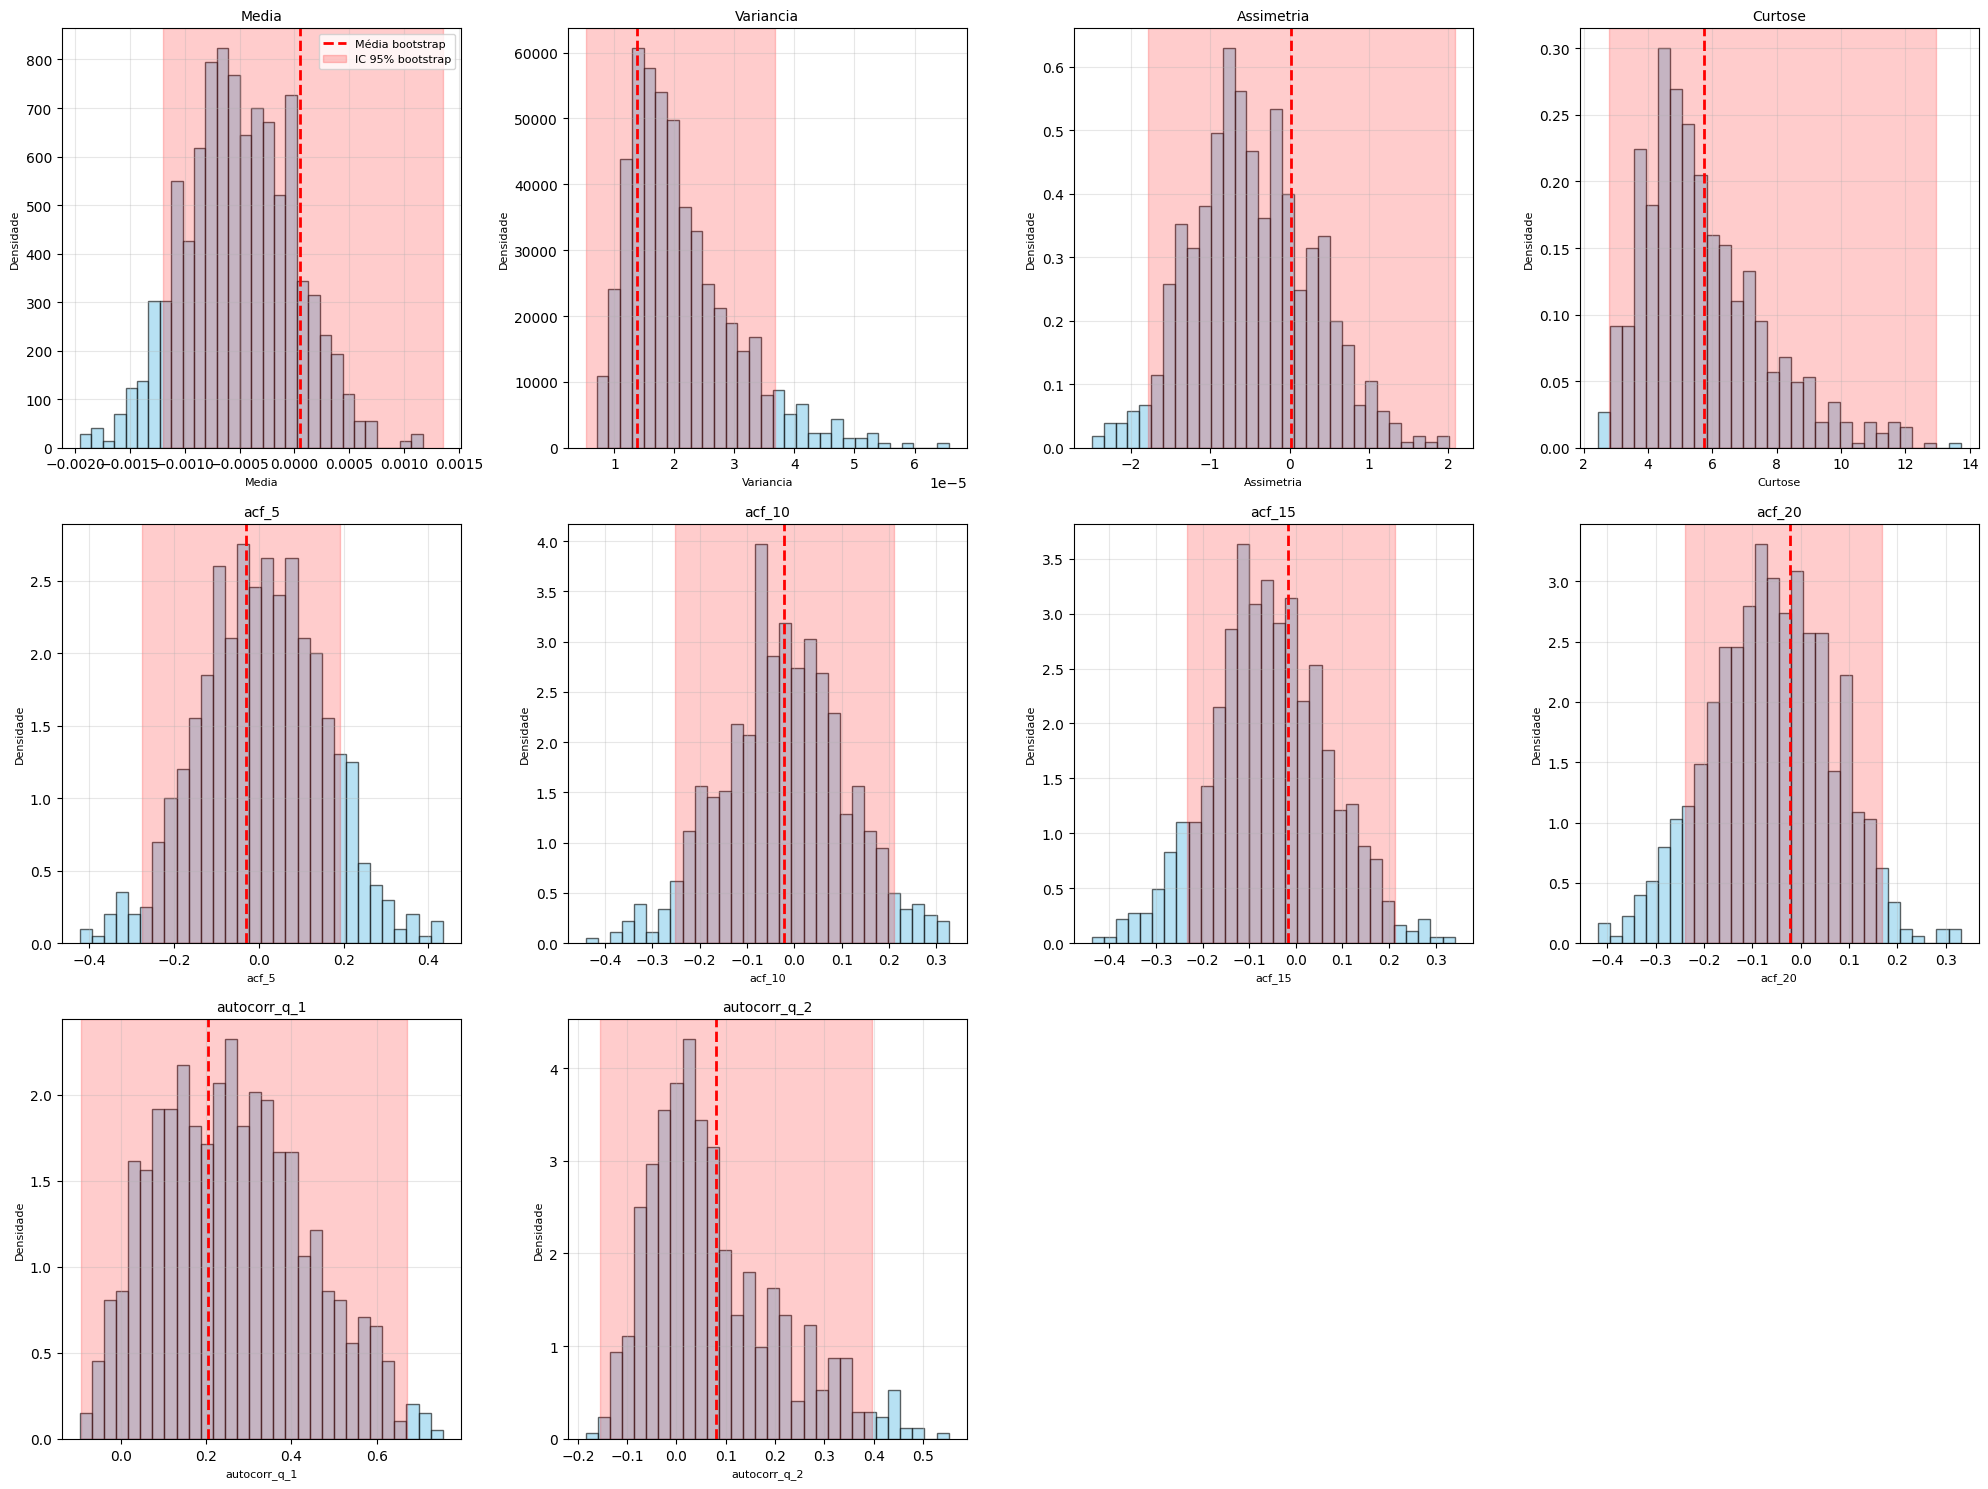

In [ ]:
plotar_distribuicoes_momentos(
    df_momentos_sim=momentos_sim_60,
    df_unica=df_referencia_empirica_60,
    bins=30
)

# Janela 500 dias

In [3]:
df_500 = pd.read_csv('/content/Mercado-Artificial-Fiis/notebooks/dados/simulacoes_validacao_500_dias.csv')

In [5]:
df_500

,Unnamed: 0,simulacao,dia,preco_fii,log_return,vol_rolante,midia_valor,sentimento_medio
0,0,1,0,21.963884,NaN,NaN,NaN,0.240983
1,1,1,1,21.993913,0.001366,NaN,NaN,0.271151
2,2,1,2,22.048098,0.002461,NaN,NaN,0.415142
3,3,1,3,22.042092,-0.000272,NaN,NaN,0.349544
4,4,1,4,22.122676,0.003649,NaN,NaN,0.299774
...,...,...,...,...,...,...,...,...
263195,263195,350,748,25.626726,0.004711,NaN,NaN,NaN
263196,263196,350,749,25.653832,0.001057,NaN,NaN,NaN
263197,263197,350,750,25.733652,0.003107,NaN,NaN,NaN
263198,263198,350,751,25.787749,0.002100,NaN,NaN,NaN


In [ ]:
momentos_bootstrap_500 = pd.read_csv("/content/Mercado-Artificial-Fiis/notebooks/dados/momentos_bootstrap_500.csv")
momentos_bootstrap_60.head()

# Calcular estatísticas por coluna
df_referencia_empirica_500 = pd.DataFrame({
    "Momento": momentos_bootstrap_60.columns,
    "Média do bootstrap": momentos_bootstrap_500.mean().values,
    "DP bootstrap": momentos_bootstrap_500.std().values,
    "IC 95% inf": momentos_bootstrap_500.quantile(0.025).values,
    "IC 95% sup": momentos_bootstrap_500.quantile(0.975).values,
})

df_referencia_empirica_500

,Momento,Média do bootstrap,DP bootstrap,IC 95% inf,IC 95% sup
0,Media,0.000031,0.000243,-0.000454,0.000512
1,Variancia,0.000014,0.000003,0.000009,0.000021
2,Assimetria,0.154954,0.667821,-0.854268,1.531713
3,Curtose,8.651156,2.518067,4.243442,13.694373
4,acf_5,0.070739,0.062490,-0.051118,0.190350
5,acf_10,-0.006074,0.047246,-0.093547,0.088684
6,acf_15,-0.005999,0.046735,-0.101424,0.085490
7,acf_20,-0.002012,0.047080,-0.095975,0.088147
8,autocorr_q_1,0.368042,0.178912,0.086816,0.633222
9,autocorr_q_2,0.244271,0.118946,0.008504,0.429600


In [ ]:
df_cobertura, joint_mcr, df_flags = cobertura_mcr(
    df_simulacoes=df_500,
    df_unica=df_referencia_empirica_500,
    num_dias=500,
    col_sim="simulacao",
    col_retorno="log_return"
)

print("Joint MCR (%):", joint_mcr)
df_cobertura

Joint MCR (%): 42.57142857142857


,Momento,Cobertura (%)
0,Media,90.857143
1,Variancia,69.428571
2,Assimetria,98.857143
3,Curtose,97.714286
4,acf_5,93.714286
5,acf_10,90.285714
6,acf_15,91.714286
7,acf_20,90.571429
8,autocorr_q_1,99.714286
9,autocorr_q_2,97.714286


In [ ]:
momentos_sim_500 = calcular_momentos_simulacoes(
    df_simulacoes=df_500,
    num_dias=500,
    col_sim="simulacao",
    col_retorno="log_return",
    lags_acf=[5, 10, 15, 20],
    lags_acf2=[1, 2],
    fft=True
)

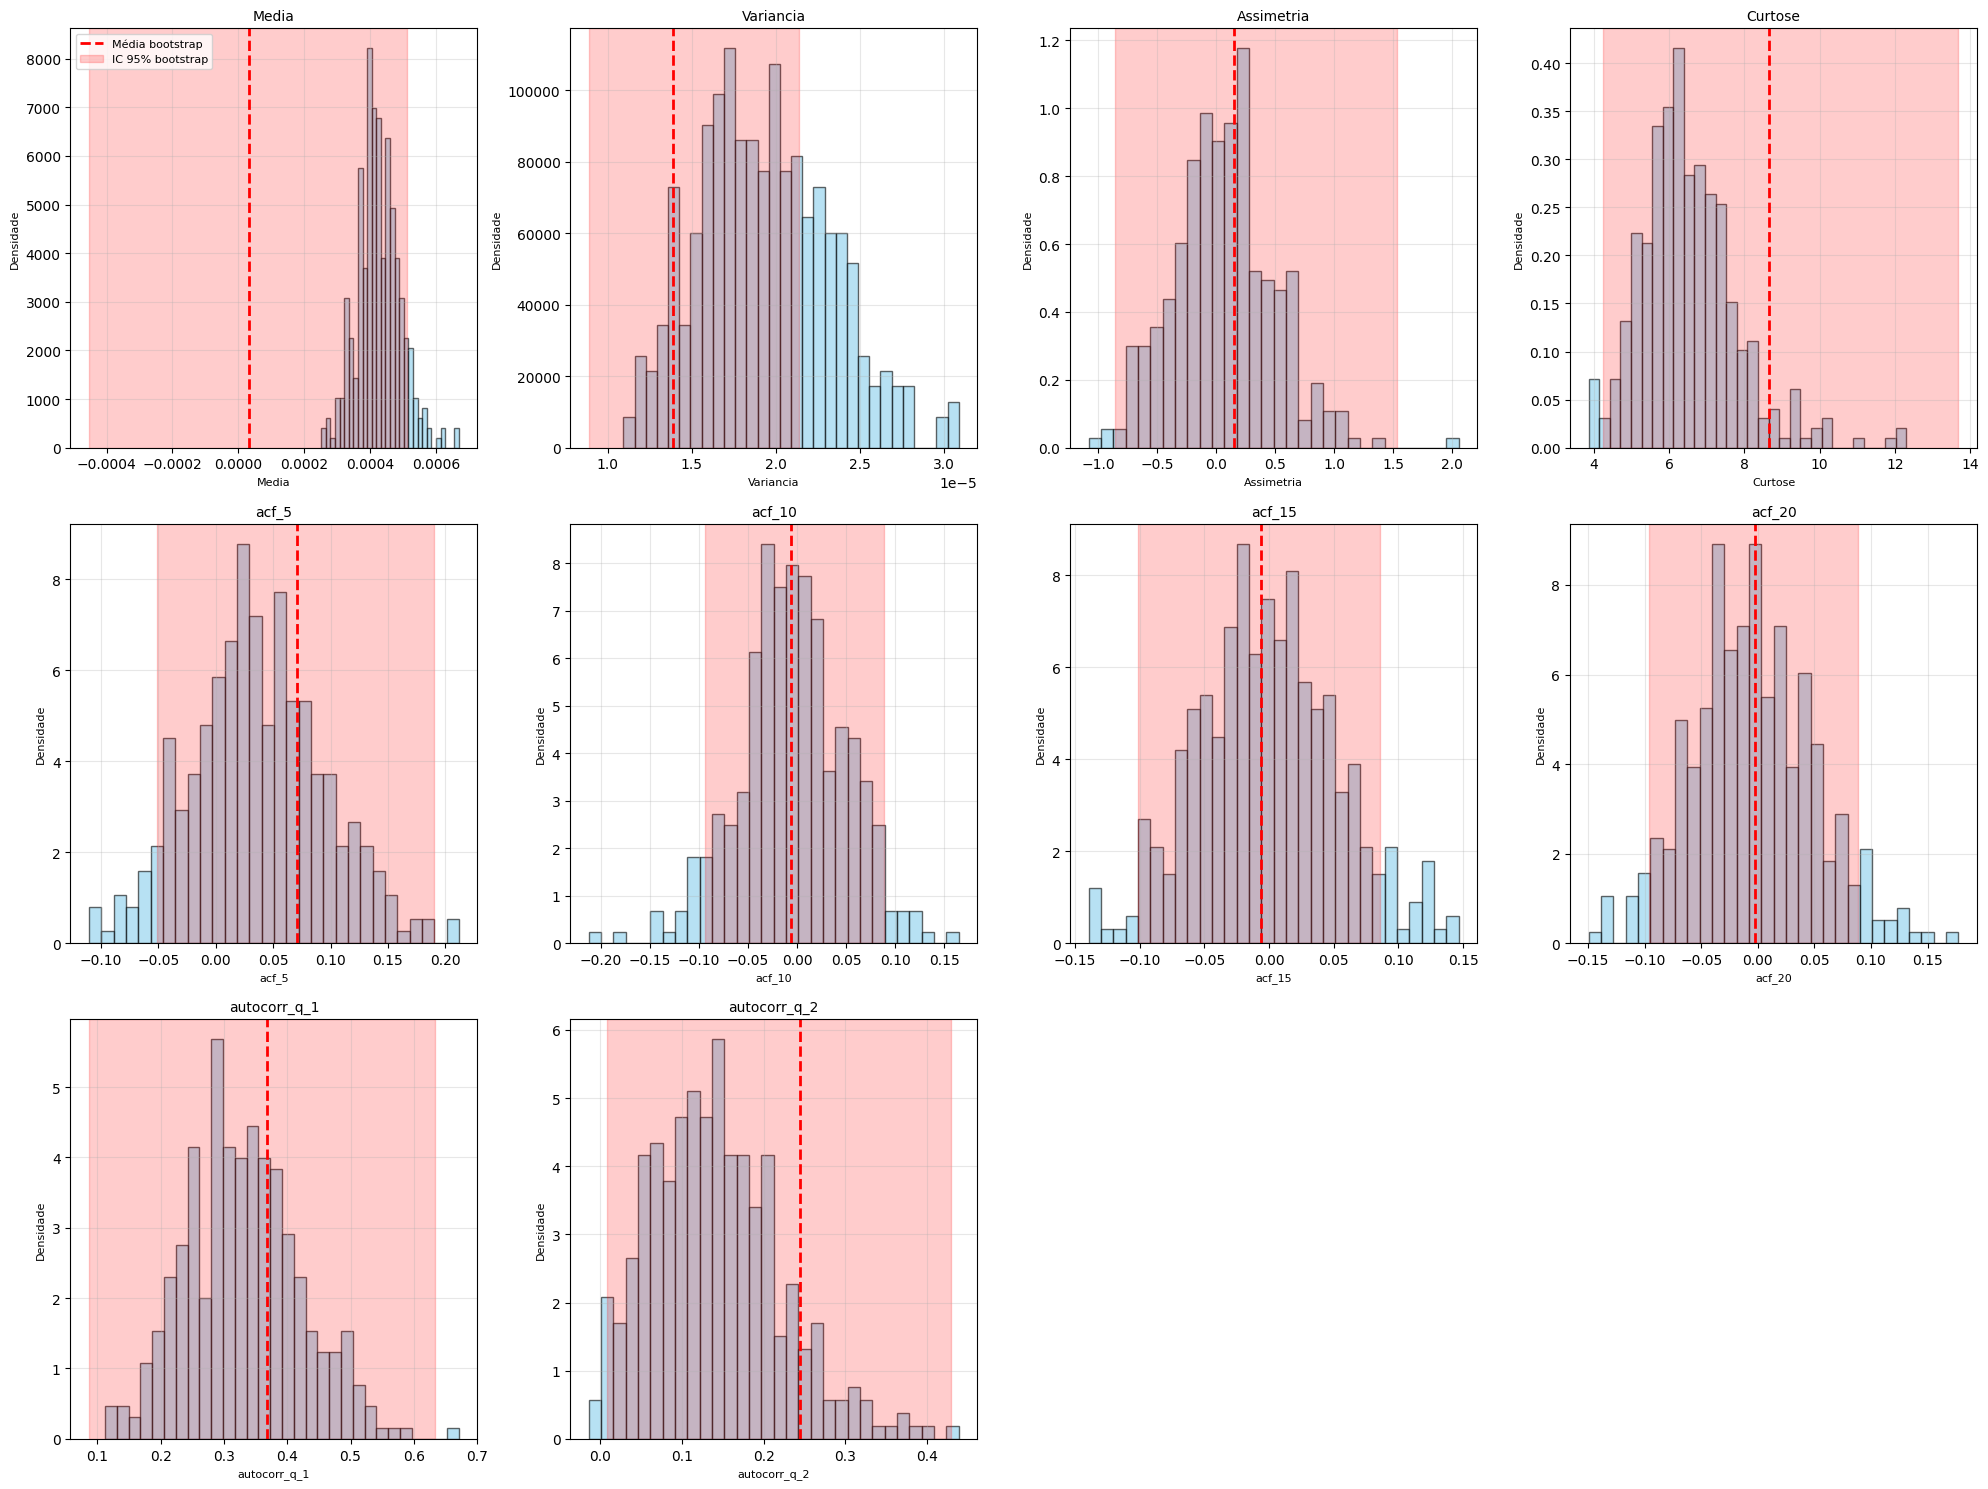

In [ ]:
plotar_distribuicoes_momentos(
    df_momentos_sim=momentos_sim_500,
    df_unica=df_referencia_empirica_500,
    bins=30
)

# Janela 500 dias

In [ ]:
df_500 = pd.read_csv('/content/series_500dias.csv')

In [ ]:
momentos_bootstrap_500 = pd.read_csv("/content/Mercado-Artificial-Fiis/notebooks/dados/momentos_bootstrap_500.csv")
momentos_bootstrap_60.head()

# Calcular estatísticas por coluna
df_referencia_empirica_500 = pd.DataFrame({
    "Momento": momentos_bootstrap_60.columns,
    "Média do bootstrap": momentos_bootstrap_500.mean().values,
    "DP bootstrap": momentos_bootstrap_500.std().values,
    "IC 95% inf": momentos_bootstrap_500.quantile(0.025).values,
    "IC 95% sup": momentos_bootstrap_500.quantile(0.975).values,
})

df_referencia_empirica_500

,Momento,Média do bootstrap,DP bootstrap,IC 95% inf,IC 95% sup
0,Media,0.000031,0.000243,-0.000454,0.000512
1,Variancia,0.000014,0.000003,0.000009,0.000021
2,Assimetria,0.154954,0.667821,-0.854268,1.531713
3,Curtose,8.651156,2.518067,4.243442,13.694373
4,acf_5,0.070739,0.062490,-0.051118,0.190350
5,acf_10,-0.006074,0.047246,-0.093547,0.088684
6,acf_15,-0.005999,0.046735,-0.101424,0.085490
7,acf_20,-0.002012,0.047080,-0.095975,0.088147
8,autocorr_q_1,0.368042,0.178912,0.086816,0.633222
9,autocorr_q_2,0.244271,0.118946,0.008504,0.429600


In [ ]:
df_cobertura, joint_mcr, df_flags = cobertura_mcr(
    df_simulacoes=df_500,
    df_unica=df_referencia_empirica_500,
    num_dias=500,
    col_sim="simulacao",
    col_retorno="log_return"
)

print("Joint MCR (%):", joint_mcr)
df_cobertura

Joint MCR (%): 50.0


,Momento,Cobertura (%)
0,Media,92.0
1,Variancia,100.0
2,Assimetria,100.0
3,Curtose,86.0
4,acf_5,94.0
5,acf_10,84.0
6,acf_15,90.0
7,acf_20,94.0
8,autocorr_q_1,100.0
9,autocorr_q_2,98.0


In [ ]:
momentos_sim_500 = calcular_momentos_simulacoes(
    df_simulacoes=df_500,
    num_dias=500,
    col_sim="simulacao",
    col_retorno="log_return",
    lags_acf=[5, 10, 15, 20],
    lags_acf2=[1, 2],
    fft=True
)

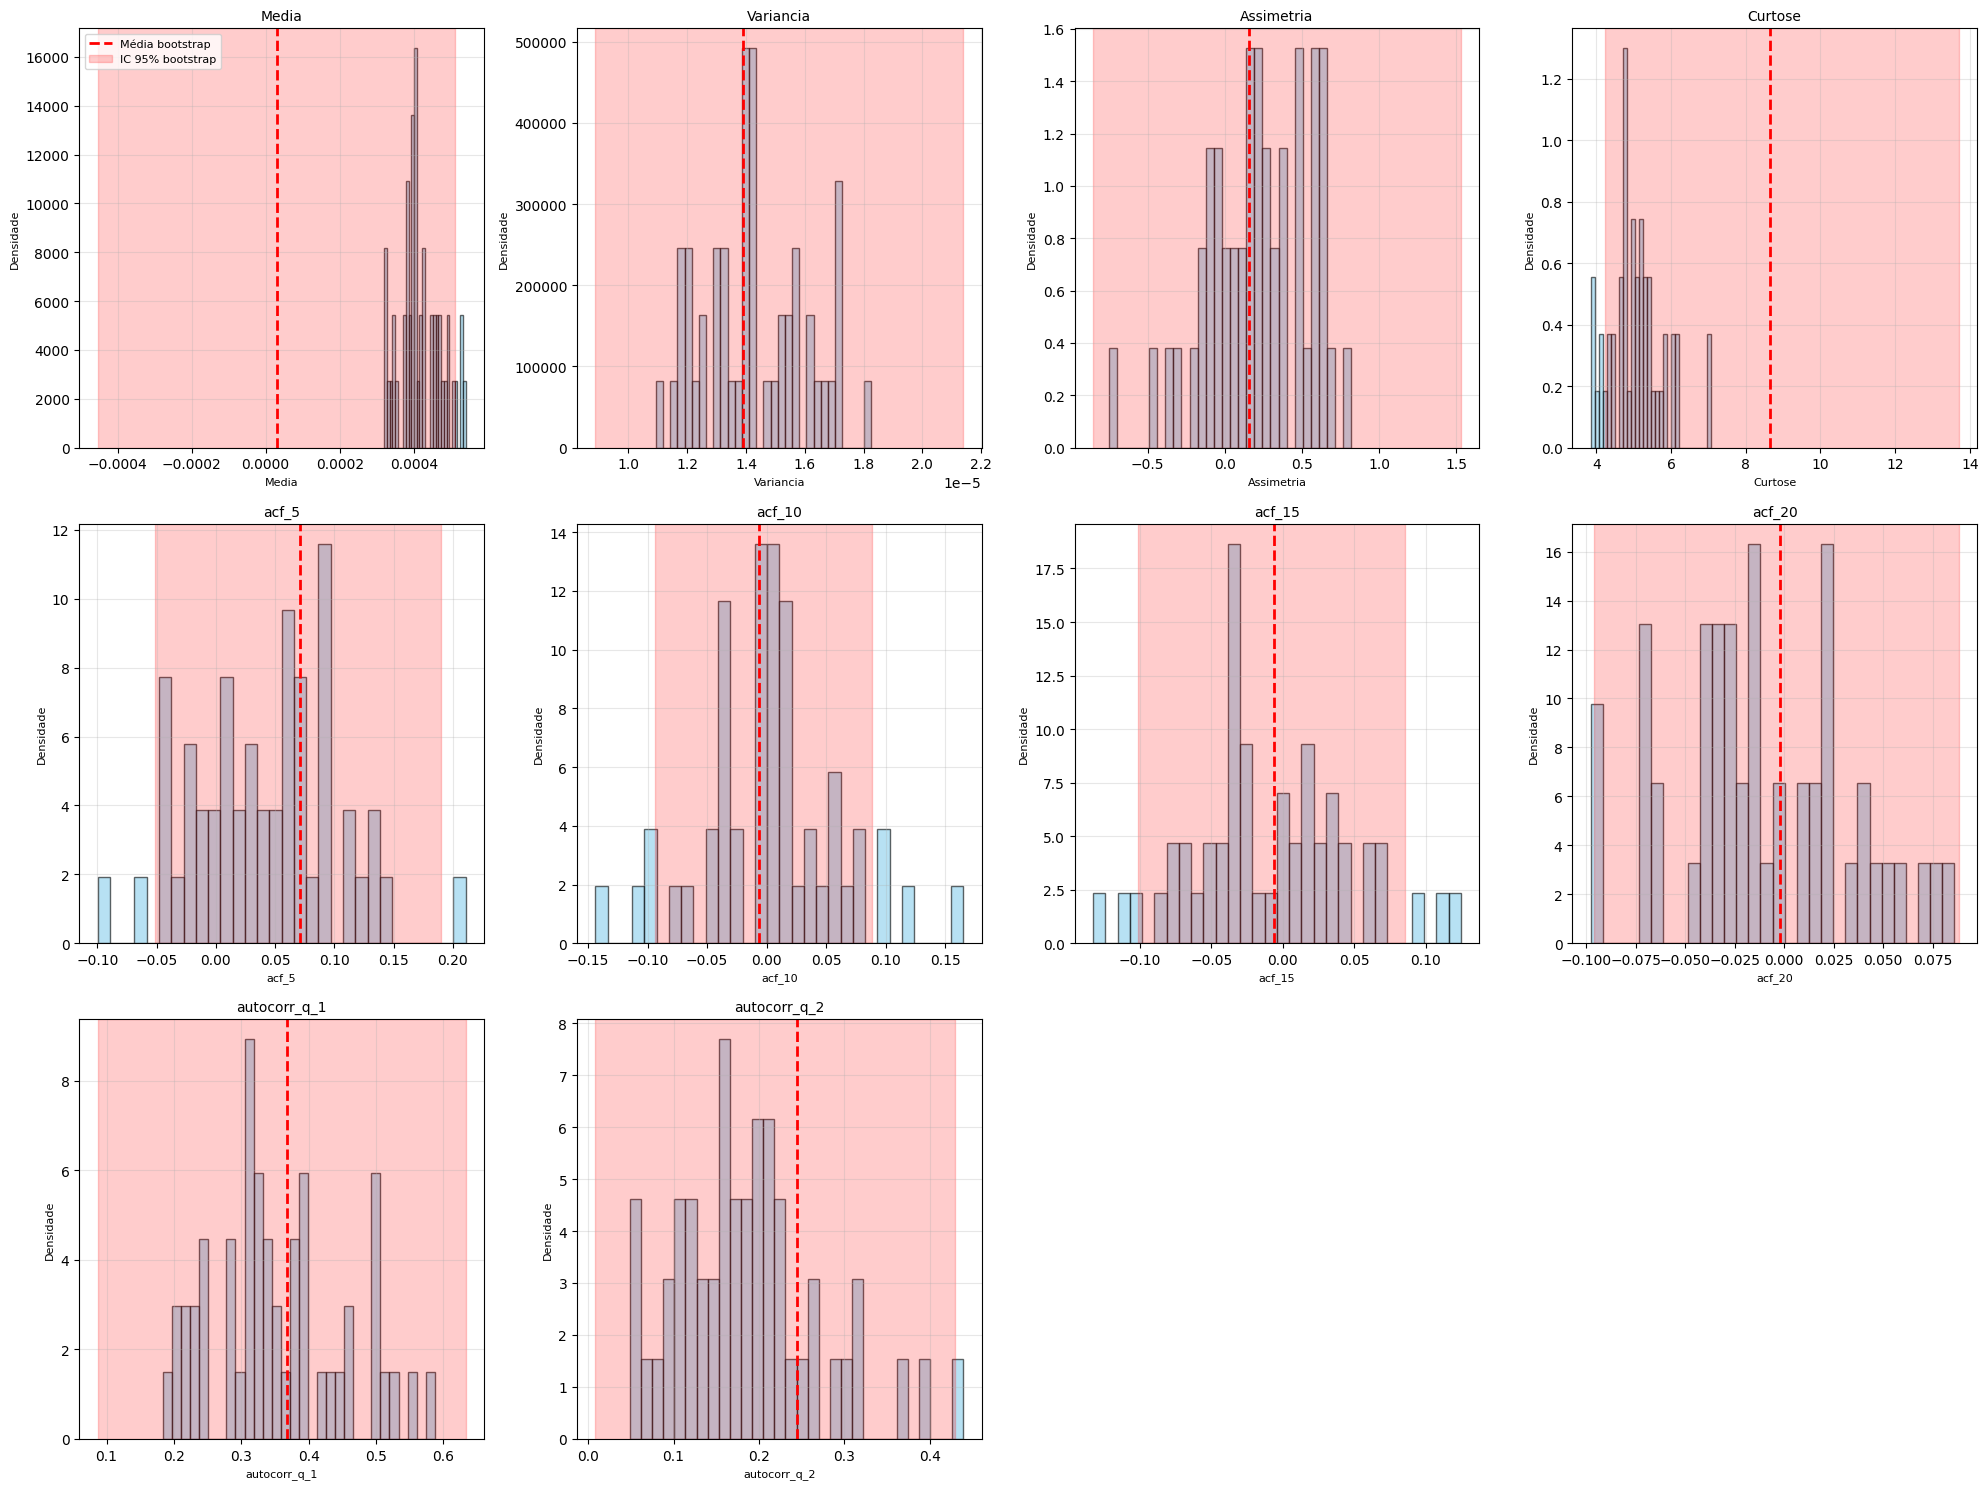

In [ ]:
plotar_distribuicoes_momentos(
    df_momentos_sim=momentos_sim_500,
    df_unica=df_referencia_empirica_500,
    bins=30
)